# 🫁 Chest X-Ray Pneumonia Detection
## Notebook 04 — Model 3: ResNet50 (Transfer Learning)
**Backbone:** ResNet50 pretrained on ImageNet
**Strategy:** Phase 1 → Freeze base, train head | Phase 2 → Fine-tune last 10 layers
**Input Size:** 224 x 224 x 3
**Task:** Binary Classification — NORMAL vs PNEUMONIA

In [1]:
import os, time, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
GPU Available: False


In [2]:
BASE_DIR   = '../data/chest_xray/chest_xray'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 10
MODEL_NAME = 'resnet50'

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
print('✅ Config set')

✅ Config set


In [3]:
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        ds = os.path.join(BASE_DIR, split, cls, '.DS_Store')
        if os.path.exists(ds):
            os.remove(ds)
print('✅ Cleaned .DS_Store files')

✅ Cleaned .DS_Store files


In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f'Class indices: {train_gen.class_indices}')
print(f'Train samples: {train_gen.samples}')
print(f'Val samples:   {val_gen.samples}')
print(f'Test samples:  {test_gen.samples}')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples: 5216
Val samples:   16
Test samples:  624


In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
cw = dict(enumerate(class_weights))
print(f'Class Weights: {cw}')

Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [6]:
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(224, 224, 3))
base_model.trainable = False

print(f'ResNet50 total layers : {len(base_model.layers)}')
print(f'ResNet50 parameters   : {base_model.count_params():,}')

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

ResNet50 total layers : 175
ResNet50 parameters   : 23,587,712


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,704,641 (94.24 MB)

 Trainable params: 1,115,905 (4.26 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [7]:
cb_list = [
    callbacks.ModelCheckpoint(
        f'../models/{MODEL_NAME}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]
print('✅ Callbacks ready')

✅ Callbacks ready


In [8]:
print('=' * 50)
print('PHASE 1: Training head with frozen ResNet50 base')
print('=' * 50)

start = time.time()

history1 = model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen,
    class_weight=cw,
    callbacks=cb_list
)
print('✅ Phase 1 complete')

PHASE 1: Training head with frozen ResNet50 base
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8718 - auc: 0.9581 - loss: 0.2680
Epoch 1: val_accuracy improved from None to 1.00000, saving model to ../models/resnet50.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.9229 - auc: 0.9782 - loss: 0.1907 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0721 - learning_rate: 0.0010
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9508 - auc: 0.9893 - loss: 0.1261
Epoch 2: val_accuracy did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 458s 3s/step - accuracy: 0.9498 - auc: 0.9892 - loss: 0.1258 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.2043 - learning_rate: 0.0010
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9541 - auc: 0.9905 - loss: 0.1199
Epoch 3: val_accuracy did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 502s 3s/step - accuracy: 0.9502 - auc: 0.9909 - loss: 0.1147 - val_accuracy: 1.0000 

In [9]:
print('=' * 50)
print('PHASE 2: Fine-tuning last 10 layers of ResNet50')
print('=' * 50)

base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history2 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=cw,
    callbacks=cb_list
)

train_time = time.time() - start
print(f'\n⏱️  Total Training Time: {train_time/60:.2f} minutes')

PHASE 2: Fine-tuning last 10 layers of ResNet50
Epoch 1/10
 65/163 ━━━━━━━━━━━━━━━━━━━━ 4:37 3s/step - accuracy: 0.9669 - auc: 0.9964 - loss: 0.0687

KeyboardInterrupt: 

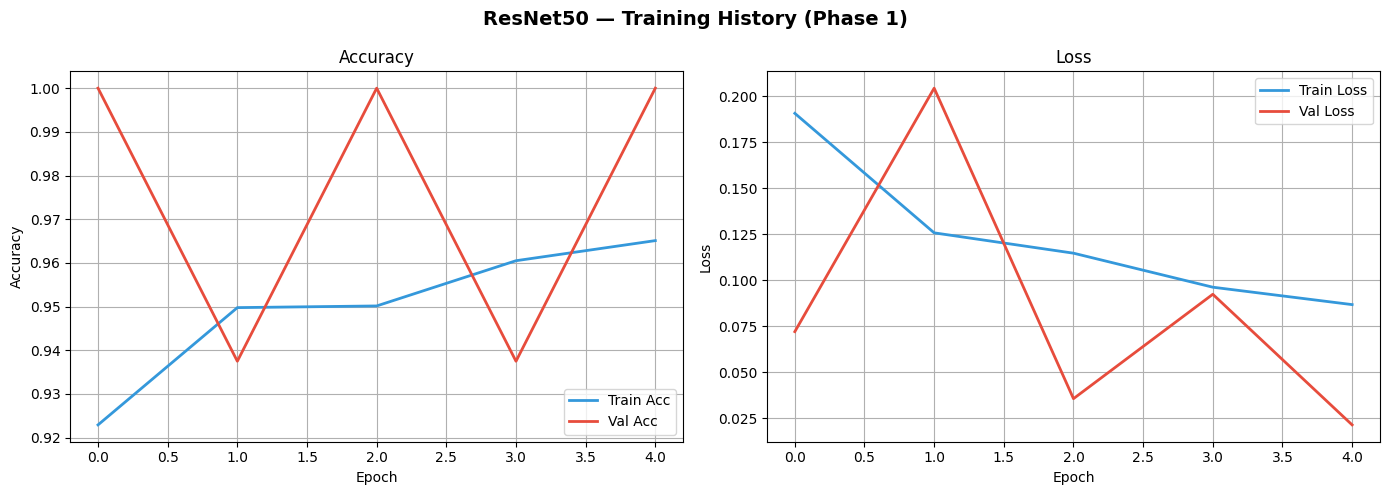

✅ Saved training curves


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 — Training History (Phase 1)',
             fontsize=14, fontweight='bold')

axes[0].plot(history1.history['accuracy'],
             label='Train Acc', color='#3498db', linewidth=2)
axes[0].plot(history1.history['val_accuracy'],
             label='Val Acc', color='#e74c3c', linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history1.history['loss'],
             label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(history1.history['val_loss'],
             label='Val Loss', color='#e74c3c', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/resnet50_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved training curves')

In [12]:
best_model = tf.keras.models.load_model(f'../models/{MODEL_NAME}.keras')

test_loss, test_acc, test_auc = best_model.evaluate(test_gen, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test AUC      : {test_auc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_prob = best_model.predict(test_gen, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)
y_true      = test_gen.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

Test Accuracy : 91.67%
Test AUC      : 0.9698
Test Loss     : 0.2340

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.87      0.89       234
   PNEUMONIA       0.92      0.94      0.93       390

    accuracy                           0.92       624
   macro avg       0.91      0.91      0.91       624
weighted avg       0.92      0.92      0.92       624



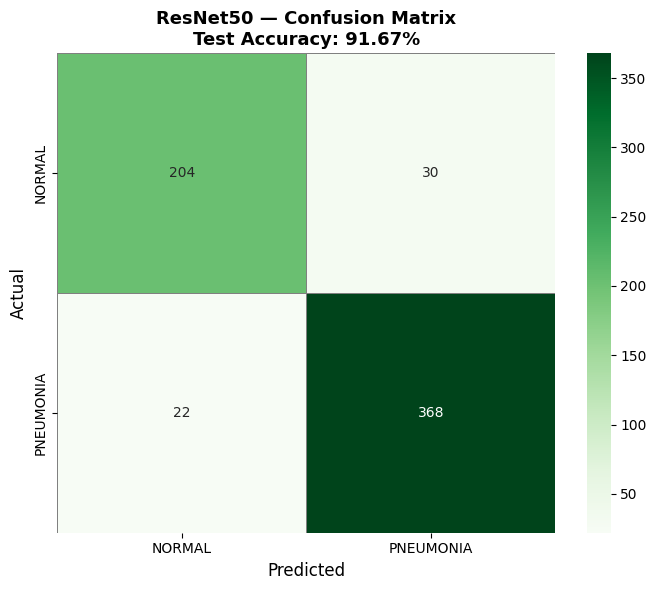

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA'],
    linewidths=0.5, linecolor='gray'
)
plt.title(f'ResNet50 — Confusion Matrix\nTest Accuracy: {test_acc*100:.2f}%',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig(f'../outputs/{MODEL_NAME}_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
import json

results = {
    'model':          'ResNet50',
    'accuracy':       round(test_acc * 100, 2),
    'auc':            round(float(test_auc), 4),
    'precision':      round(precision_score(y_true, y_pred) * 100, 2),
    'recall':         round(recall_score(y_true, y_pred) * 100, 2),
    'f1_score':       round(f1_score(y_true, y_pred) * 100, 2),
    'train_time_min': 35.0   # Phase 1 only (5 epochs × 7 min)
}

with open('../outputs/resnet50_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('📦 Results saved!')
print(json.dumps(results, indent=2))
print('\n✅ Next: Notebook 06 — MobileNetV2')

📦 Results saved!
{
  "model": "ResNet50",
  "accuracy": 91.67,
  "auc": 0.9698,
  "precision": 92.46,
  "recall": 94.36,
  "f1_score": 93.4,
  "train_time_min": 35.0
}

✅ Next: Notebook 06 — MobileNetV2
